In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io  # For loading MATLAB data

def color_region(region_mask, color):
    """
    根据二进制掩码生成彩色区域图像。
    """
    colored_region_mask = np.zeros((*region_mask.shape, 3))
    
    # 设置颜色通道
    if color == 'red':
        colored_region_mask[..., 0] = region_mask  # Red channel
    elif color == 'green':
        colored_region_mask[..., 1] = region_mask  # Green channel
    elif color == 'blue':
        colored_region_mask[..., 2] = region_mask  # Blue channel
    elif color == 'yellow':
        colored_region_mask[..., 0] = region_mask  # Red channel for yellow
        colored_region_mask[..., 1] = region_mask  # Green channel for yellow
    return colored_region_mask

def combine_layers(inner_set, middle_set, outer_set, colors):
    """
    手动组合每个层的颜色，确保每层都不透明。
    """
    # 创建黑色背景
    combined_image = np.zeros((*inner_set.shape, 3))
    
    # 按顺序叠加 outer_set (蓝色)，middle_set (黄色)，inner_set (红色)
    combined_image = np.where(outer_set[..., None], color_region(outer_set, colors[0]), combined_image)
    combined_image = np.where(middle_set[..., None], color_region(middle_set, colors[1]), combined_image)
    combined_image = np.where(inner_set[..., None], color_region(inner_set, colors[2]), combined_image)
    
    return combined_image

def crplot(inner_set, outer_set, middle_set, color_scheme=None, background=None):
    """
    绘制具有不同置信区间的区域，确保每一层都是不透明的。
    """
    if background is None:
        background = np.zeros((inner_set.shape[0], inner_set.shape[1], 3))  # 黑色背景
    
    # 默认颜色方案，确保 outer_set 是蓝色
    if color_scheme is None:
        color_scheme = ['blue', 'yellow', 'red']  # outer_set 为蓝色
    
    # 生成合并后的图像
    combined_image = combine_layers(inner_set, middle_set, outer_set, color_scheme)
    
    # 显示最终合成的图像
    plt.imshow(background)
    plt.imshow(combined_image, alpha=1.0)  # 完全不透明显示
    plt.axis('off')

In [4]:
def CI_fwer(scores, masks, alpha=0.05):
    """
    Calculate the threshold for family-wise error rate (FWER) in conformal inference.
    Parameters:
    scores (ndarray): 3D array of statistical scores where the last dimension represents different images.
    masks (ndarray): 3D binary array indicating the mask for each image, matching the scores array.
    alpha (float): Significance level for FWER.
    Returns:
    tuple: threshold for FWER, array of maximum values per image after masking.
    """
    nimages = scores.shape[-1]
    max_vals = np.zeros(nimages) # max_vals 用来存储每个样本在非掩码区域的最大分数。

    for i in range(nimages):
        # masked_image = scores[..., i] * (1 - masks[..., i].astype(float)) # 原始代码有问题,可能是python不能兼容的原因
        masked_image = np.nan_to_num(scores[..., i] * (1 - masks[..., i].astype(float)), nan=0.0, posinf=0.0, neginf=0.0)
        #这种方式将 NaN 和极端值（inf 和 -inf）替换为 0，从而避免了绘图或计算过程中出现问题。
        max_vals[i] = masked_image.max()
        # print(max_vals[i])
    threshold = np.percentile(max_vals, 100 * (1 - alpha))  
    
    # 绘制 max_vals 的分布和阈值
    plt.figure(figsize=(10, 6))
    plt.hist(max_vals, bins=30, color='skyblue', edgecolor='black', density=True)
    plt.axvline(threshold, color='red', linestyle='--', label=f'{(1 - alpha) * 100}% Threshold: {threshold:.2f}')
    plt.xlabel('Max values')
    plt.ylabel('Density')
    plt.title(f'Distribution of Maximum Values (Threshold at {100 * (1 - alpha)}th percentile)')
    plt.legend()
    plt.show()
    
    return threshold, max_vals



In [5]:
import numpy as np
import scipy.io

gt_masks_path = '/home/pxl/myProject/血管分割/molong-深度插值/molong-work/simple-unet-2d/inference-output/topo-FIVE-my/gt_masks.npy'
scores_path = '/home/pxl/myProject/血管分割/molong-深度插值/molong-work/simple-unet-2d/inference-output/topo-FIVE-my/scores.npy'

gt_masks = np.load(gt_masks_path)
scores = np.load(scores_path)

# 重塑数组
gt_masks = np.transpose(gt_masks, (1, 2, 0))
scores = np.transpose(scores, (1, 2, 0))
print("成功加载gt_masks和scores文件")
print(f"gt_masks形状: {gt_masks.shape}")
print(f"scores形状: {scores.shape}")

# 定义切片参数
patch_size = 64  # 每个切片的大小
stride = 32  # 切片的步长

# 创建切片
patches_scores = []
patches_masks = []
h, w = scores.shape[0], scores.shape[1]

for img_idx in range(scores.shape[2]):
    for i in range(0, h-patch_size+1, stride):
        for j in range(0, w-patch_size+1, stride):
            score_patch = scores[i:i+patch_size, j:j+patch_size, img_idx]
            mask_patch = gt_masks[i:i+patch_size, j:j+patch_size, img_idx]
            # 检查mask_patch是否全为0
            if np.any(mask_patch):  # 如果mask_patch中有任何非0值
                patches_scores.append(score_patch)
                patches_masks.append(mask_patch)

# 将切片转换为numpy数组
patches_scores = np.array(patches_scores)
patches_masks = np.array(patches_masks)

# 重塑数组为所需的形状
patches_scores = np.transpose(patches_scores, (1, 2, 0))
patches_masks = np.transpose(patches_masks, (1, 2, 0))

print(f"切片后的形状:")
print(f"patches_scores形状: {patches_scores.shape}")
print(f"patches_masks形状: {patches_masks.shape}")

# 随机打乱切片顺序
total_patches = patches_scores.shape[2]
shuffle_idx = np.random.permutation(total_patches)
patches_scores = patches_scores[:, :, shuffle_idx]
patches_masks = patches_masks[:, :, shuffle_idx]

# 分割为校准集和验证集
n_val = 50  # 验证集数量
val_idx = np.arange(n_val)
cal_idx = np.arange(n_val, total_patches)

# 提取数据子集
cal_scores = patches_scores[:, :, cal_idx]
val_scores = patches_scores[:, :, val_idx]
cal_gt_masks = patches_masks[:, :, cal_idx]
val_gt_masks = patches_masks[:, :, val_idx]

print(f"\n数据集划分:")
print(f"校准集大小: {cal_scores.shape[2]} 个切片")
print(f"验证集大小: {val_scores.shape[2]} 个切片")

成功加载gt_masks和scores文件
gt_masks形状: (2048, 2048, 30)
scores形状: (2048, 2048, 30)
切片后的形状:
patches_scores形状: (64, 64, 56906)
patches_masks形状: (64, 64, 56906)

数据集划分:
校准集大小: 56856 个切片
验证集大小: 50 个切片


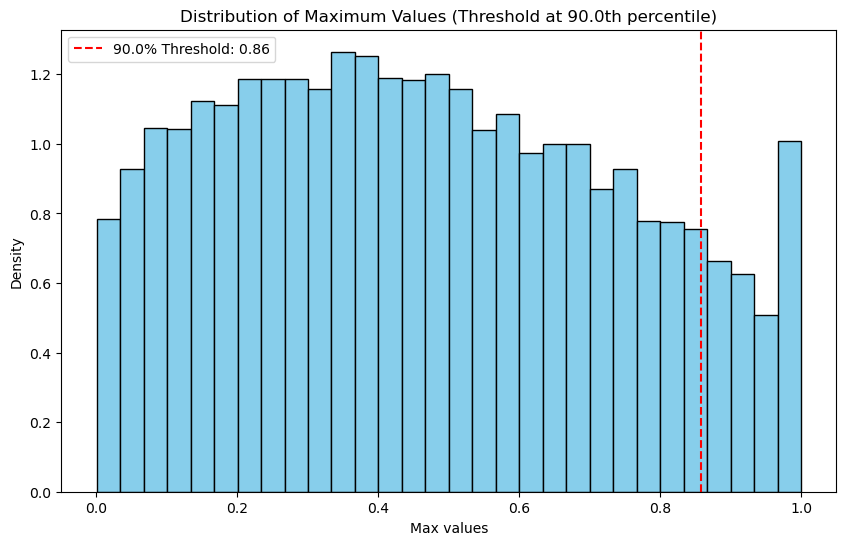

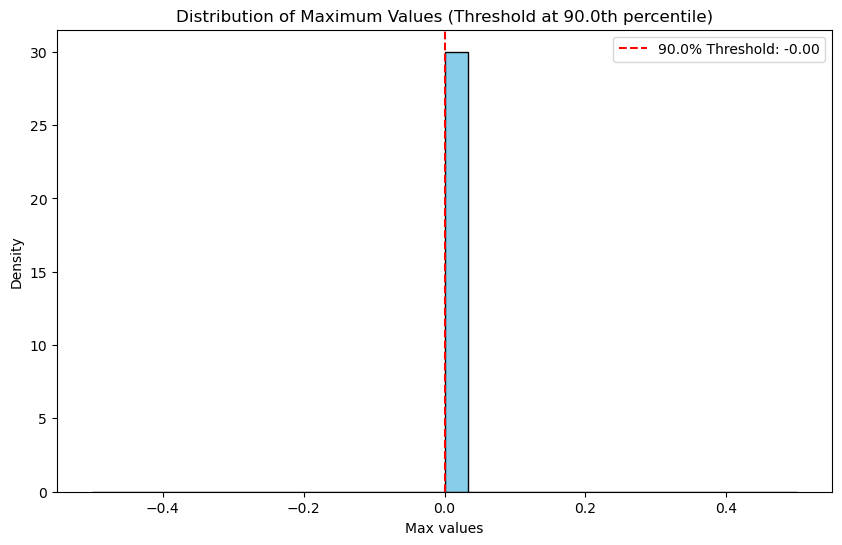

0.8578521907329559
-0.0


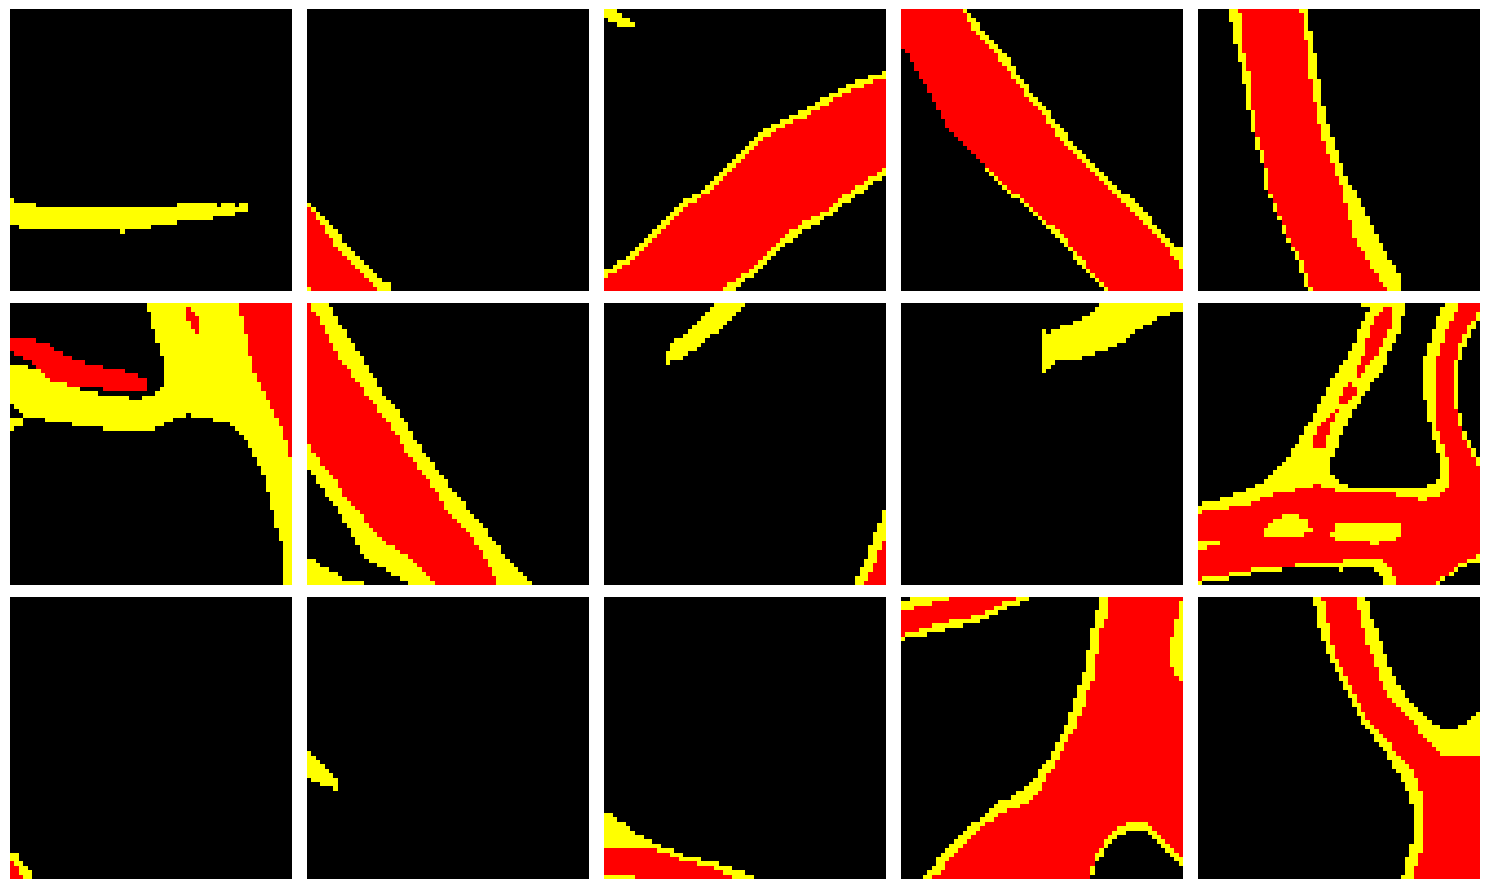

In [7]:
alpha1 = 0.1
alpha2 = 0.1

# alpha1 = 0.05
# alpha2 = 0.05

# alpha1 = 0.02
# alpha2 = 0.02

# 计算内外置信阈值
threshold_inner, _ = CI_fwer(cal_scores, cal_gt_masks, alpha1)
threshold_outer, _ = CI_fwer(-cal_scores, 1 - cal_gt_masks, alpha2)

print(threshold_inner)
print(threshold_outer)
# 创建3x5网格用于显示图像
fig, axs = plt.subplots(3, 5, figsize=(15, 9))
for i, ex in enumerate(np.random.choice(val_idx, size=15, replace=False)):
    # 提取当前示例的分数图和掩码
    score_im = patches_scores[:, :, ex]
    mask = patches_masks[:, :, ex]

    # 生成内层和外层的二值掩码
    predicted_inner = score_im > threshold_inner  # 内层区域掩码

    # 在当前子图上使用 crplot 函数绘制区域
    ax = axs.flat[i]
    plt.sca(ax)  # 设置当前子图为活动子图
    crplot(predicted_inner, predicted_inner, mask)  # 绘制 outer, middle, inner
    
plt.tight_layout()
plt.show()


2


/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1588391/3849736257.py:73: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from curren

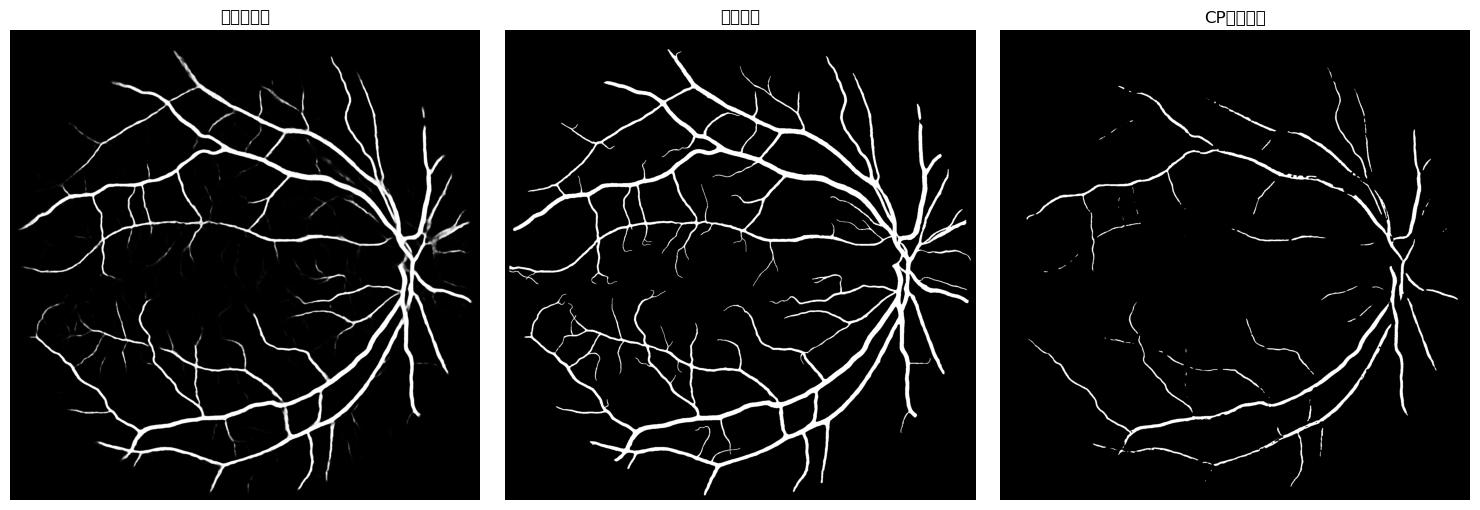

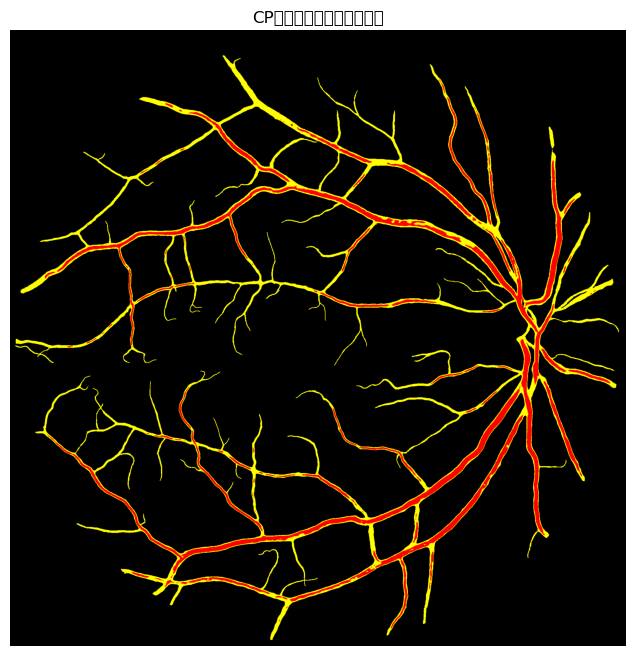

In [218]:
#写个代码，对整张图片进行推断，再具体逻辑中，按照原先切片逻辑，再对每个切片进行cp推断，然后再组装起来，形成最终校准结果
#补充：我已经有了预测结果：val_scores，从这里面随机挑选一个进行测试

def process_full_image_cp(full_score, threshold, patch_size=64, stride=32):
    """
    对整张图片进行CP推断
    
    参数:
    full_score: 完整图片的预测分数 (h, w)
    threshold: CP推断的阈值
    patch_size: 切片大小
    stride: 步长
    
    返回:
    result_map: 完整的CP推断结果图 (h, w)
    """
    h, w = full_score.shape
    # 创建结果图和计数图
    result_map = np.zeros((h, w))
    count_map = np.zeros((h, w))
    
    # 对图片进行切片处理
    for i in range(0, h-patch_size+1, stride):
        for j in range(0, w-patch_size+1, stride):
            # 提取当前切片
            score_patch = full_score[i:i+patch_size, j:j+patch_size]
            
            # 对切片进行CP推断
            predicted_patch = (score_patch > threshold).astype(float)
            
            # 将结果累加到结果图中
            result_map[i:i+patch_size, j:j+patch_size] += predicted_patch
            count_map[i:i+patch_size, j:j+patch_size] += 1
    
    # 计算平均值（处理重叠区域）
    result_map = np.divide(result_map, count_map, where=count_map>0)
    
    # 将结果二值化（可以根据需要调整阈值）
    final_result = (result_map > 0.5).astype(float)
    
    return final_result

# 测试代码
# 从val_scores中随机选择一个样本
# test_idx = np.random.randint(0, scores.shape[2])
test_idx = 2
print(test_idx)
test_score = scores[:, :, test_idx]
test_mask = gt_masks[:, :, test_idx]

# 进行CP推断
# cp_result = process_full_image_cp(test_score, 0.1)
cp_result = test_score>threshold_inner

# 可视化结果
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.imshow(test_score, cmap='gray')
plt.title('原始分数图')
plt.axis('off')

plt.subplot(132)
plt.imshow(test_mask, cmap='gray')
plt.title('真实标签')
plt.axis('off')

plt.subplot(133)
plt.imshow(cp_result, cmap='gray')
plt.title('CP推断结果')
plt.axis('off')

plt.tight_layout()
plt.show()

# 使用之前的crplot函数显示结果
plt.figure(figsize=(8, 8))
crplot(cp_result, cp_result, test_mask)
plt.title('CP推断结果与真实标签对比')
plt.show()

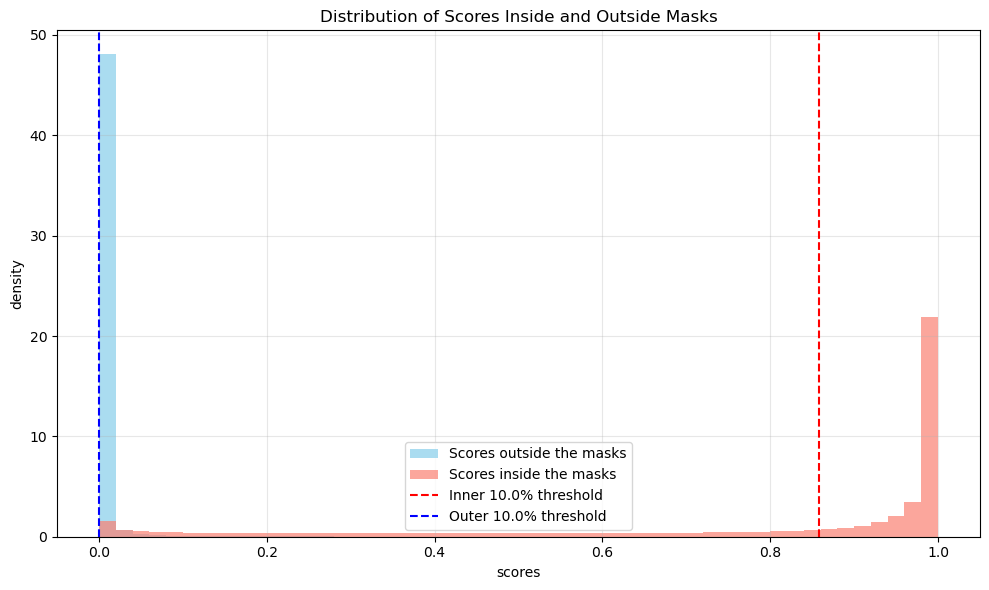

In [221]:
# 提取mask内外的scores
scores_inside = []
scores_outside = []

# 遍历所有图片
for i in range(scores.shape[2]):
    score = scores[..., i]
    mask = gt_masks[..., i]
    
    scores_inside.extend(score[mask > 0].flatten())
    scores_outside.extend(score[mask == 0].flatten())

# 转换为numpy数组
scores_inside = np.array(scores_inside)
scores_outside = np.array(scores_outside)

# 创建直方图
plt.figure(figsize=(10, 6))

# 设置直方图参数
bins = 50
alpha = 0.7

# 绘制两个直方图
plt.hist(scores_outside, bins=bins,density=True, alpha=alpha, color='skyblue', 
         label='Scores outside the masks')
plt.hist(scores_inside, bins=bins, density=True,alpha=alpha, color='salmon', 
         label='Scores inside the masks')

# 添加阈值线
plt.axvline(x=threshold_inner, color='red', linestyle='--', 
            label=f'Inner {alpha1*100}% threshold')
plt.axvline(x=threshold_outer, color='blue', linestyle='--', 
            label=f'Outer {alpha2*100}% threshold')

# 设置图表属性
plt.xlabel('scores')
plt.ylabel('density')
# plt.yscale('log')  # 使用对数刻度
plt.title('Distribution of Scores Inside and Outside Masks')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

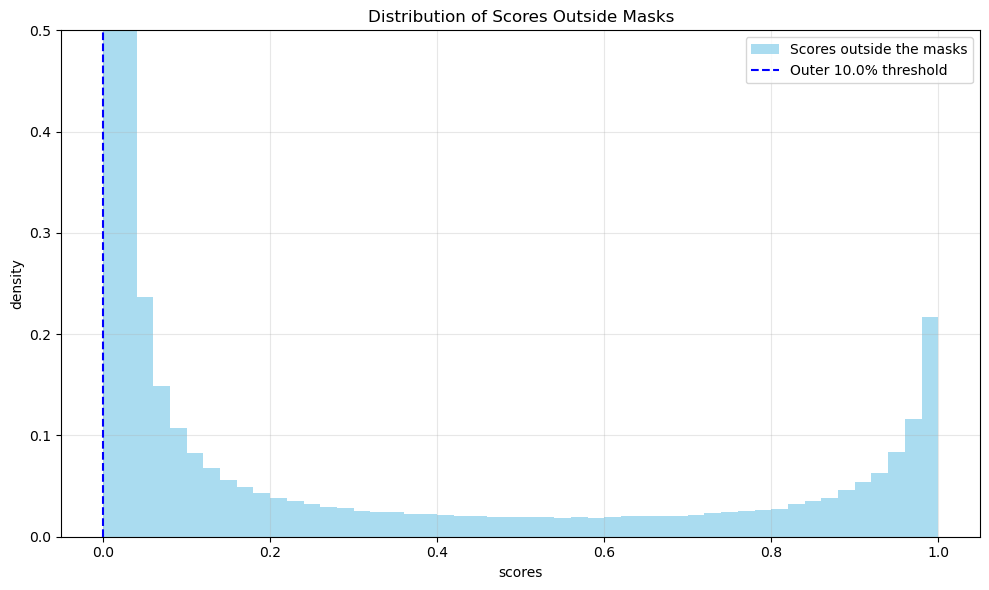

In [206]:
# 对scores中所有像素点进行直方图统计，只统计mask外的点
scores_outside = []

# 遍历所有图片
for i in range(scores.shape[2]):
    score = scores[..., i]
    mask = gt_masks[..., i]
    
    # 只收集mask外的scores
    scores_outside.extend(score[mask == 0].flatten())

# 转换为numpy数组
scores_outside = np.array(scores_outside)

# 创建直方图
plt.figure(figsize=(10, 6))

# 设置直方图参数
bins = 50
alpha = 0.7

# 只绘制mask外的直方图
plt.hist(scores_outside, bins=bins, density=True, alpha=alpha, color='skyblue', 
         label='Scores outside the masks')

# 添加阈值线
plt.axvline(x=threshold_outer, color='blue', linestyle='--', 
            label=f'Outer {alpha1*100}% threshold')

# 设置图表属性
plt.xlabel('scores')
plt.ylabel('density')
plt.title('Distribution of Scores Outside Masks')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 0.5)  # 设置y轴范围为0-0.5

plt.tight_layout()
plt.show()
